In [58]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [189]:
class Value:
    def __init__(self, data, children=(), _op='', label= ''):
        self.data= data
        self._backward = lambda : None
        self.grad = 0.0
        self._prev = set(children)
        self._op = _op
        self.label=label


        # in the grad oof add mul and tanh i did += thats for the case where we use a variable more than once so that we dont just overwrite
        # but actuallt accumilate the gradients 
    def __repr__(self):
        return f"Value(data = {self.data})"
        
    def __add__(self,other):
        out = Value(self.data +other.data, (self,other), '+')
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out 
        
    def __mul__(self,other):
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad+=out.grad * self. data
            
        out._backward = _backward
        return out

    # def __sub__(self,other):
    #     return Value(self.data - other.data, (self,other),'-')

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/ (math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh' )
        def _backward():
            self.grad += (1- t**2) * out.grad
        out._backward = _backward 
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
            topo.append(v)
        build_topo(o) 
        self.grad=1
        for element in reversed(topo):
            element._backward()
        

# so basically my class here takes some numbers and can do basic operations addition and multiplication

a = Value(2.0, label='a')
b = Value(-3.0,label='b')
c= Value(10.0,label='c')
e= a*b ; e.label='e'
d= e+ c; d.label='d'
f = Value(-2.0 , label = 'f')
L= d*f ; L.label='L'




In [166]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # For any value in the graph, create a rectangular ('record') node
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            # If this value is a result of some operation, create an op node
            dot.node(
                name=uid + n._op,
                label=n._op
            )

            # Connect the op node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

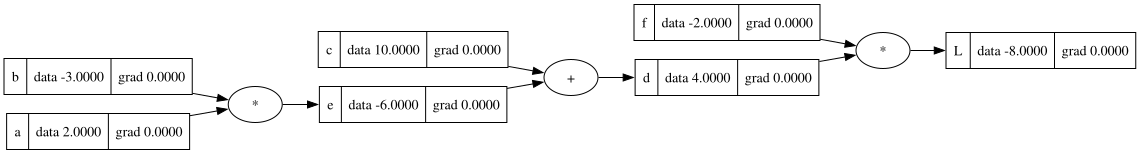

In [167]:
draw_dot(L)
# the grad represents the derivative of te output, in this case 'L' with respect the the value we are in. 

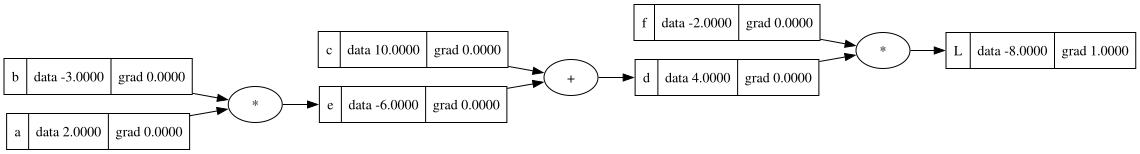

In [168]:
# manual backpropagation : 
L.grad=1.0 # derivative of L in respect to L 
draw_dot(L)

In [169]:
# manual backpropagation
def test():
    h= 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0,label='b')
    c= Value(10.0,label='c')
    e= a*b ; e.label='e'
    d= e+ c; d.label='d'
    f = Value(-2.0 , label = 'f')
    L= d*f ; L.label='L'

    L1 = L.data
    
    a = Value(2.0 , label='a')
    b = Value(-3.0,label='b')
    c= Value(10.0,label='c')
    e= a*b ; e.label='e'
    d= e+ c; d.label='d'
    f = Value(-2.0 + h , label = 'f')
    L= d*f ; L.label='L'
    L2= L.data 
    print((L2 - L1 ) / h)    # dL/df 

test()



    

3.9999999999995595


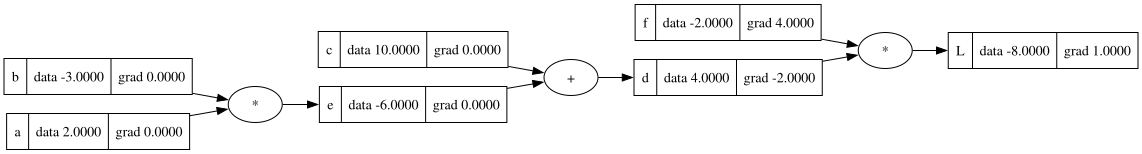

In [170]:
# L = d*f
# dL/dd = f
d.grad = f.data   # L = d * f , thus dL/dd = f
f.grad = d.data   # dL/df = d thus f.grad = d
draw_dot(L)
# can also make sure that this is correct by using the h variable in the previous cell to get the result 

# added the grad of the second layer 

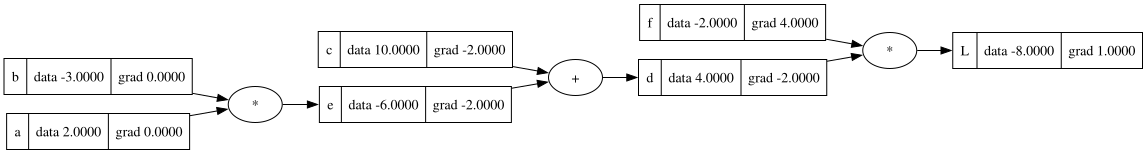

In [171]:
# notice that : dL/dc= dL/dd * dd/dc (chain rule in calc)
# therefor we can simply get the dL/dc by multiplying the orevious result by the dd/dc 

    # dd/dc = 1
    # dd/de = 1
    
    # WANT : 
    # dL/dc = dL/dd * dd/dc = -2.0 * 1 = -2.0
    # dL/de = dL/dd * dd/de = -2.0 * 1 = -2.0
    
    # HAVE : 
    # dL/dd = -2.0
    # dd/dc = 1.0
    # dd/de= 1 
c.grad = -2
e.grad = -2

# added the grad of the firstt layer

draw_dot(L)

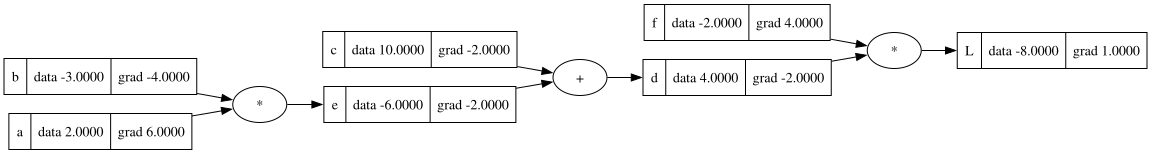

In [172]:

#     NEED :
#     dL/da
#     dL/db 

#     COMPUTE :
#     de/da = b = -3
#     de/db = a = 2

#     THUS : 
#     dL/da = dL/de * de/da  = -2 * -3 = 6
#     dL/db = dL/de * de/db = -2 * 2 = -4

a.grad = 6
b.grad = -4
draw_dot(L)

# added the grad of first layer ____ DONE

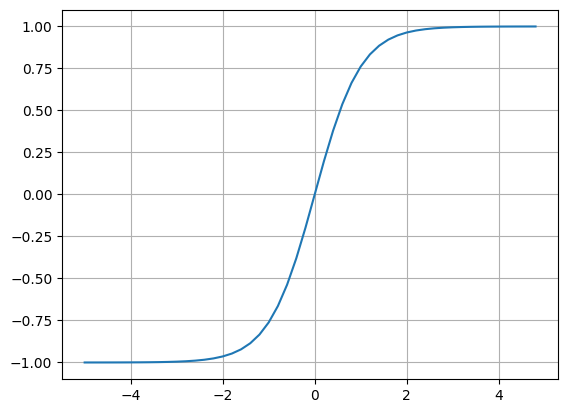

In [173]:
# introduce the tanh function as it will be used later on (can also used other funcs such as sigmoid ....)
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))) ; plt.grid()

In [174]:
#input x1 x2
x1 = Value(2,label= 'x1')
x2 = Value(0,label= 'x2')
#weights w1 w2
w1 = Value(-3,label= 'w1')
w2 = Value (1,label= 'w2')
# bias b
b = Value(6.8813735870195432, label = 'b')

#operations
x1w1 = x1 * w1 ; x1w1.label = 'x1w1'
x2w2 = x2 * w2 ; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh() ; o.label = 'o'

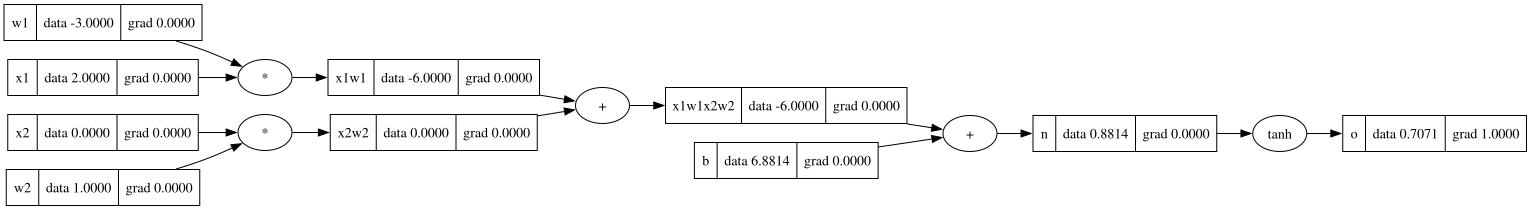

In [175]:
o.grad = 1
draw_dot(o) 

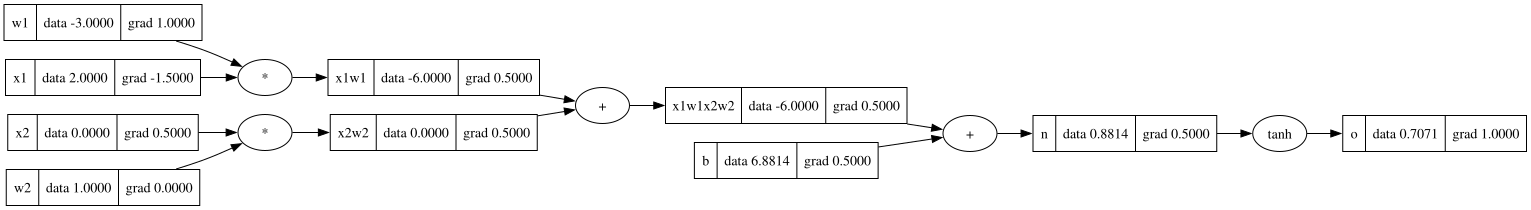

In [176]:
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1- o**2
# o.data # = 0.7071067811865476
n.grad = 1- o.data**2

# third layer grad
x1w1x2w2.grad = 0.5
b.grad = 0.5

#second layer grad
x1w1.grad = 0.5
x2w2.grad = 0.5

# first layer grad 
x2.grad = w2.data * 0.5
w2.grad = x2.data * 0.5
x1.grad = w1.data * 0.5
w1.grad = x1.data * 0.5



draw_dot(o) 

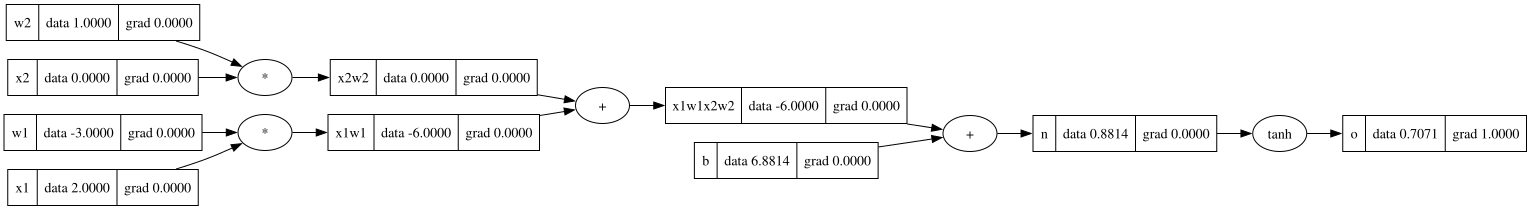

In [177]:
# now lets try automatic backpropagation, i added to the class (_backwards ) which is supposed to compute the grad on it sown, lets try
#input x1 x2
x1 = Value(2,label= 'x1')
x2 = Value(0,label= 'x2')
#weights w1 w2
w1 = Value(-3,label= 'w1')
w2 = Value (1,label= 'w2')
# bias b
b = Value(6.8813735870195432, label = 'b')

#operations
x1w1 = x1 * w1 ; x1w1.label = 'x1w1'
x2w2 = x2 * w2 ; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh() ; o.label = 'o'
o.grad=1

draw_dot(o)


In [178]:
o._backward()

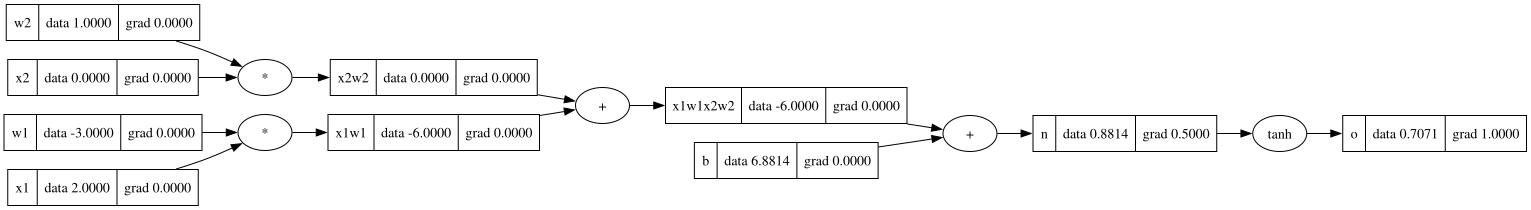

In [179]:
draw_dot(o)

In [180]:
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

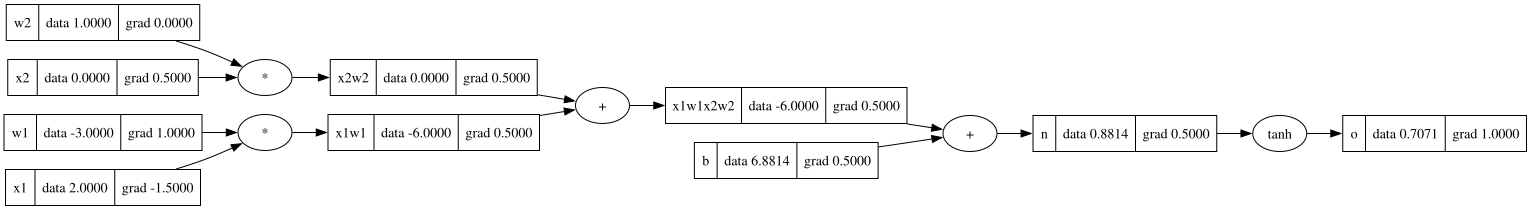

In [181]:
draw_dot(o)

In [182]:
# now we want to do the automatic backpropagation withouy the need to write manually the backward function
# here is a topological list such that all the elements are going to a single way left to right

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for element in reversed(topo):
    element._backward

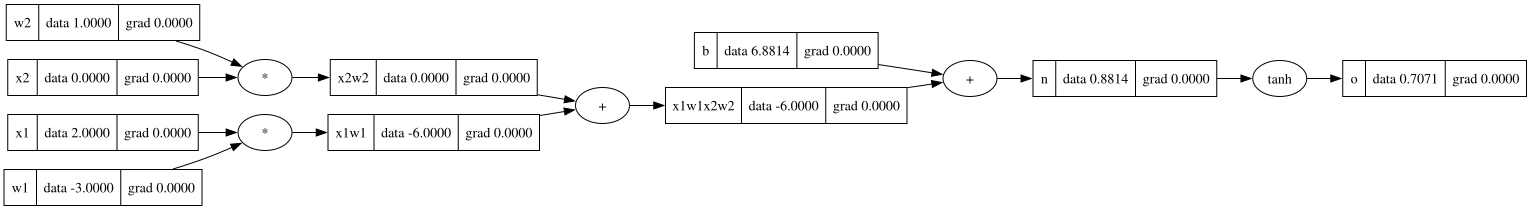

In [185]:
# here is a clear example of it : 


x1 = Value(2,label= 'x1')
x2 = Value(0,label= 'x2')
#weights w1 w2
w1 = Value(-3,label= 'w1')
w2 = Value (1,label= 'w2')
# bias b
b = Value(6.8813735870195432, label = 'b')

#operations
x1w1 = x1 * w1 ; x1w1.label = 'x1w1'
x2w2 = x2 * w2 ; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh() ; o.label = 'o'

draw_dot(o)

In [186]:
o.backward()

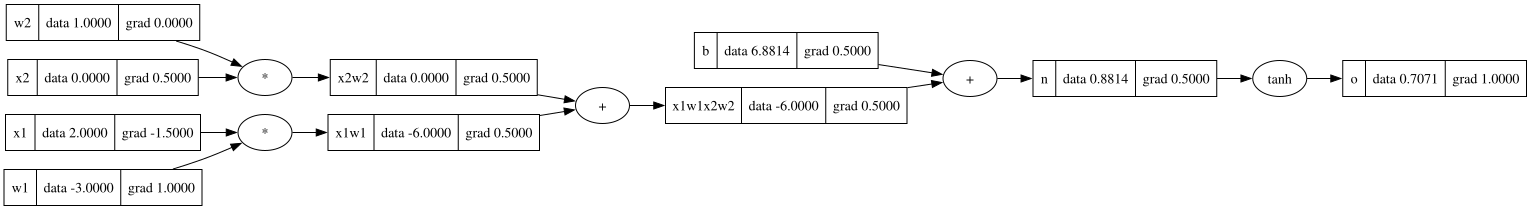

In [188]:
draw_dot(o)     # now it computes the back automatically we only have to write the backward of the last node in the graph